# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Raihan Nurhakim              |5054251030       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.



data = pd.read_csv('D:/Visual_Studio_Code/ML 2026/Praktikum-ML/1.Tugas_KNN/WineQT.csv')
data.head()
data.info()


! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


'Cari' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

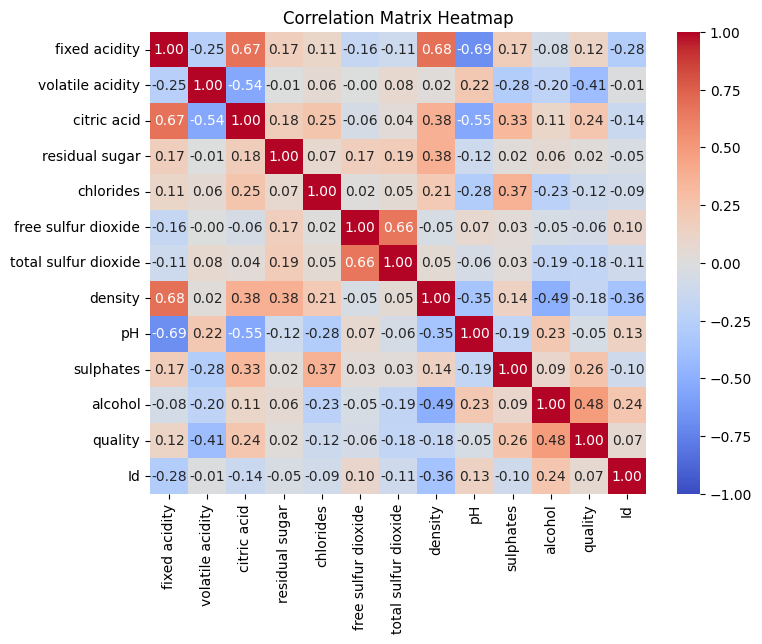

In [4]:
# Tampilkan Korelasi Matrix
df = pd.DataFrame(data)
corr_matrix = df.corr()
print(df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

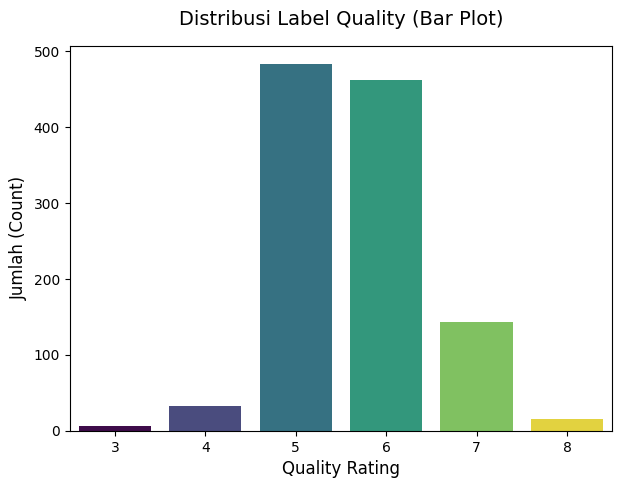

In [5]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="quality", hue="quality", palette="viridis", legend=False)

plt.title("Distribusi Label Quality (Bar Plot)", fontsize=14, pad=15)
plt.xlabel("Quality Rating", fontsize=12)
plt.ylabel("Jumlah (Count)", fontsize=12)

plt.show()


## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [6]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nQuality distribution:')
print(df['quality'].value_counts().sort_index())
print(f'\nBasic stats:')
df.describe().round(2)

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Duplicates: 0

Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Basic stats:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66,804.97
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81,464.00
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00,0.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00,411.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00,794.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00,1209.50
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00,1597.00


In [7]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

df = df.drop('Id', axis=1)
print("dropped Id column ")

dfbfr = len(df)
df = df.drop_duplicates()
print("duplicates dropped :", (dfbfr - len(df)))

df['quality_label'] = (df['quality'] >= 6).astype(int)

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

print("Jumlah data setelah preprocessing:", len(df))
print("\nDistribusi target:")
print(y.value_counts())

print("\nPersentase target:")
print(y.value_counts(normalize=True) * 100)

dropped Id column 
duplicates dropped : 125
Jumlah data setelah preprocessing: 1018

Distribusi target:
quality_label
1    546
0    472
Name: count, dtype: int64

Persentase target:
quality_label
1    53.634578
0    46.365422
Name: proportion, dtype: float64


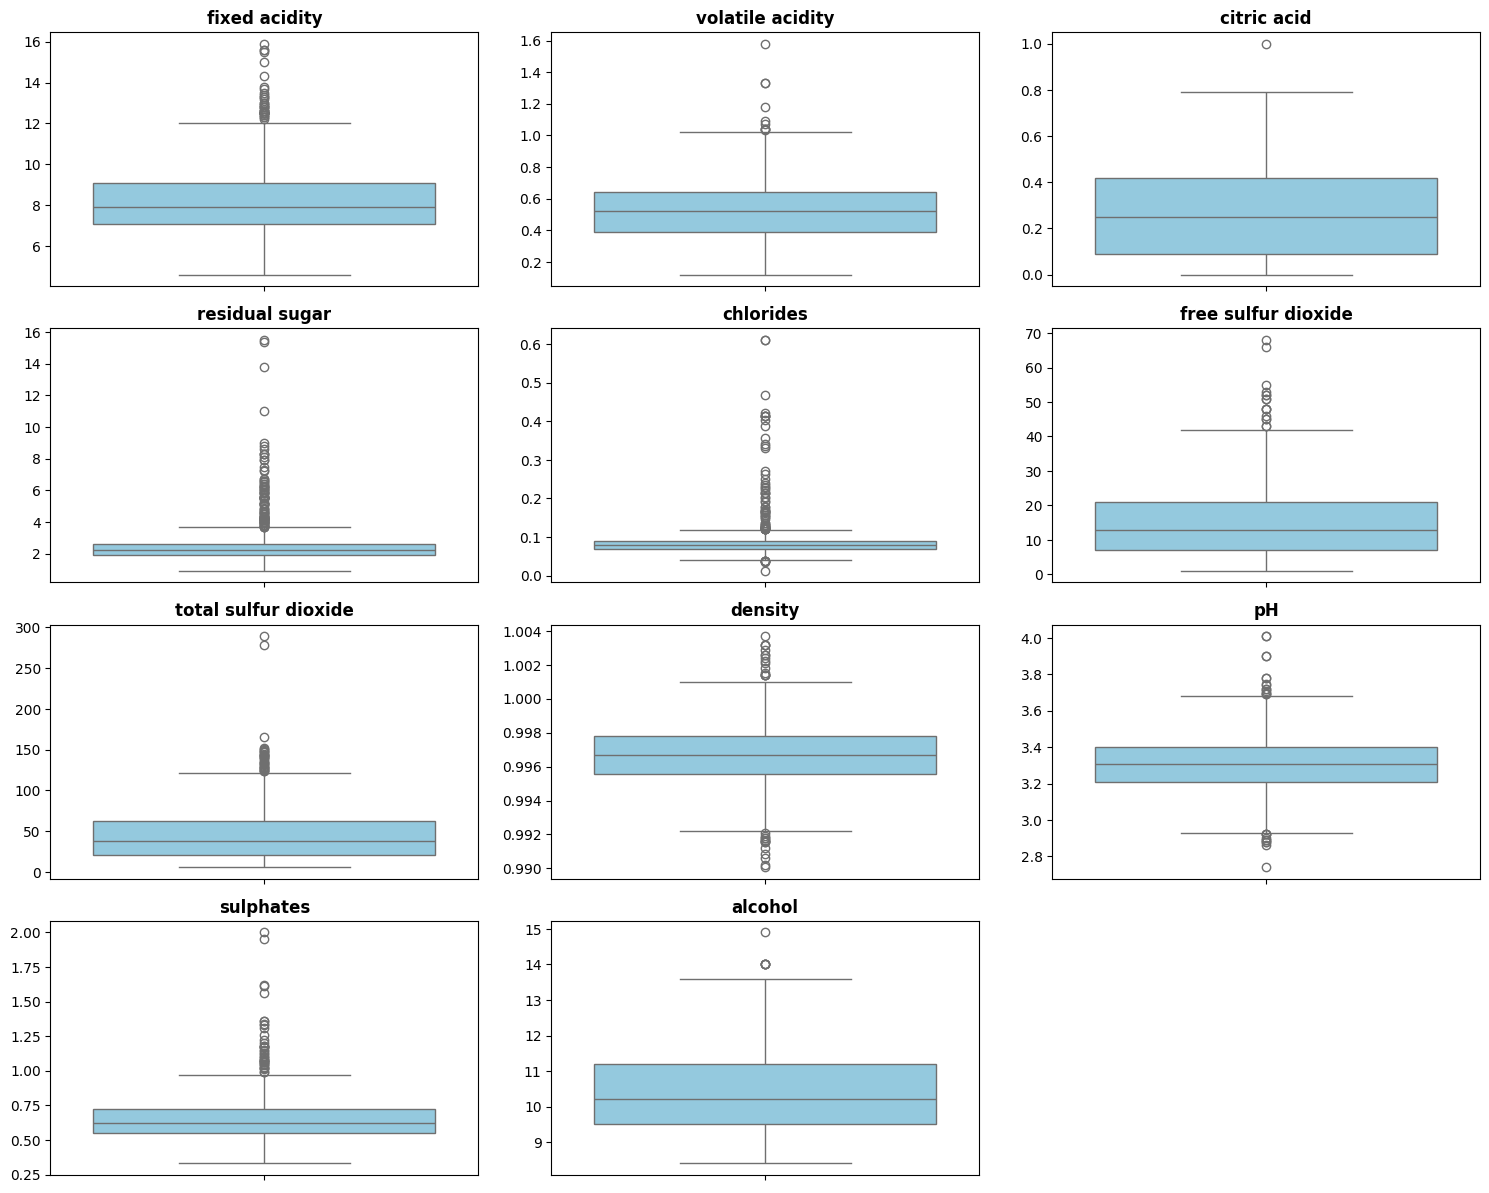

In [8]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
features = [col for col in df.columns if col != 'quality']

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

# Looping plot boxplot tiap kolom ke sel masing-masing
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

# Sembunyikan sel terakhir yang kosong (karena hanya ada 11 fitur)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# raw
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

# std
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_train_std, y_train)
acc_std = accuracy_score(y_test, knn_std.predict(X_test_std))

# minmax
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

knn_mm = KNeighborsClassifier(n_neighbors=5)
knn_mm.fit(X_train_mm, y_train)
acc_mm = accuracy_score(y_test, knn_mm.predict(X_test_mm))

print(f"Akurasi Tanpa Scaling : {acc_raw:.4f}")
print(f"Akurasi StandardScaler: {acc_std:.4f}")
print(f"Akurasi MinMaxScaler  : {acc_mm:.4f}")


Akurasi Tanpa Scaling : 0.5882
Akurasi StandardScaler: 0.7157
Akurasi MinMaxScaler  : 0.7255


# 3. Eksperimen Model KNN


In [38]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

k_values = [3, 5, 7, 9, 11, 15, 21, 31, 33, 35]

metrics = ['euclidean', 'manhattan']

results = []

for met in metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=met)

        cv_scores = cross_val_score(knn, X_train_std, y_train, cv=5, scoring='accuracy')

        knn.fit(X_train_std, y_train)

        train_acc = knn.score(X_train_std, y_train)

        train_acc = knn.score(X_train_std,y_train)

        results.append({
            'metric': met,
            'k': k,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'train_acc': train_acc
        })

results_df = pd.DataFrame(results)

results_df

,metric,k,cv_mean,cv_std,train_acc
0,euclidean,3,0.692843,0.026707,0.846437
1,euclidean,5,0.697713,0.038999,0.807125
2,euclidean,7,0.716163,0.022514,0.788698
3,euclidean,9,0.711285,0.018866,0.773956
4,euclidean,11,0.719889,0.009536,0.769042
5,euclidean,15,0.717451,0.012724,0.759214
6,euclidean,21,0.706370,0.013506,0.743243
7,euclidean,31,0.727259,0.015071,0.740786
8,euclidean,33,0.737082,0.008712,0.742015
9,euclidean,35,0.737090,0.007519,0.742015


In [39]:
best_idx = results_df['cv_mean'].idxmax()

best_model = results_df.iloc[best_idx]

print("=== Best Model ===")
print(f"Distance Metric : {best_model['metric']}")
print(f"K Value         : {int(best_model['k'])}")
print(f"CV Accuracy     : {best_model['cv_mean']:.4f}")
print(f"CV Std          : {best_model['cv_std']:.4f}")
print(f"Train Accuracy  : {best_model['train_acc']:.4f}")

=== Best Model ===
Distance Metric : manhattan
K Value         : 33
CV Accuracy     : 0.7408
CV Std          : 0.0206
Train Accuracy  : 0.7506


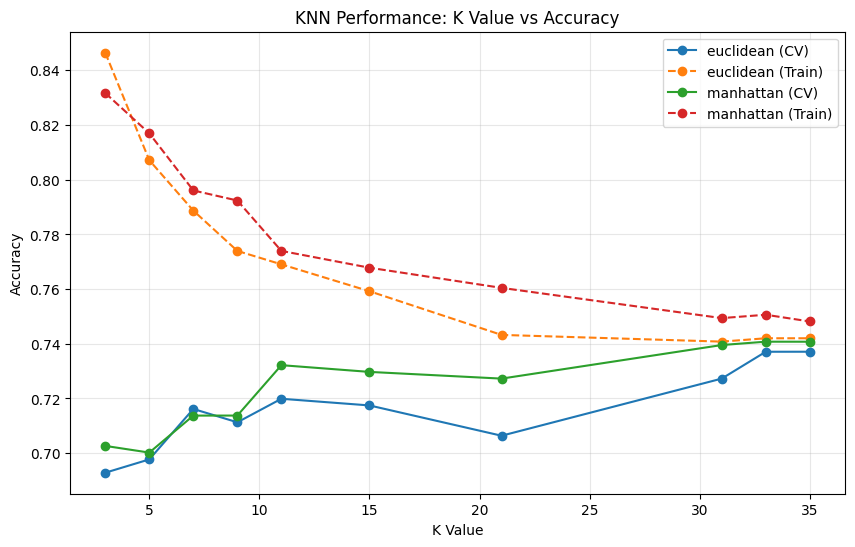

In [40]:
plt.figure(figsize=(10, 6))

for metric in metrics:

    metric_df = results_df[results_df['metric'] == metric]

    plt.plot(metric_df['k'], metric_df['cv_mean'], 'o-', label=f'{metric} (CV)')

    plt.plot(metric_df['k'], metric_df['train_acc'], 'o--', label=f'{metric} (Train)')

plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Performance: K Value vs Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
best_knn = KNeighborsClassifier(n_neighbors=int(best_model['k']), metric=best_model['metric'])

best_knn.fit(X_train_std, y_train)

y_pred = best_knn.predict(X_test_std)

# 4. Evaluasi Model


=== Test Set Performance ===
Accuracy: 0.7157

Classification Report:
               precision    recall  f1-score   support

Bad/Avg (3-5)       0.68      0.74      0.71        95
   Good (6-8)       0.75      0.70      0.72       109

     accuracy                           0.72       204
    macro avg       0.72      0.72      0.72       204
 weighted avg       0.72      0.72      0.72       204



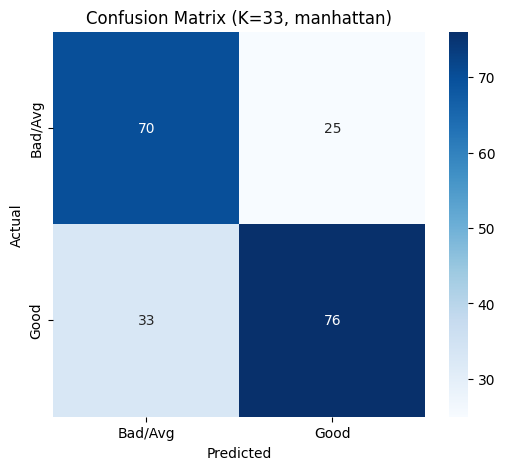

In [42]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)

print("=== Test Set Performance ===")
print(f"Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")

print(classification_report(
        y_test,
        y_pred,
        target_names=[
            'Bad/Avg (3-5)',
            'Good (6-8)'
        ]
    )
)
plt.show()


# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bad/Avg', 'Good'],
    yticklabels=['Bad/Avg', 'Good']
)

plt.title(
    f'Confusion Matrix (K={int(best_model["k"])}, '
    f'{best_model["metric"]})'
)

plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [43]:
results_df_sorted = results_df.sort_values(
    by='cv_mean',
    ascending=False
)

results_df_sorted

,metric,k,cv_mean,cv_std,train_acc
18,manhattan,33,0.740763,0.020608,0.750614
19,manhattan,35,0.740748,0.020832,0.748157
17,manhattan,31,0.739536,0.018751,0.749386
9,euclidean,35,0.737090,0.007519,0.742015
8,euclidean,33,0.737082,0.008712,0.742015
14,manhattan,11,0.732175,0.014528,0.773956
15,manhattan,15,0.729713,0.013773,0.767813
7,euclidean,31,0.727259,0.015071,0.740786
16,manhattan,21,0.727259,0.022319,0.760442
4,euclidean,11,0.719889,0.009536,0.769042


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

## Analisis

Pada eksperimen awal, klasifikasi dilakukan berdasarkan nilai `quality` asli yang terdiri dari 6 kelas, yaitu quality 3 hingga 8. Berdasarkan hasil eksperimen, model KNN menghasilkan accuracy pada kisaran 52%–58%. Hasil tersebut menunjukkan bahwa model masih mengalami kesulitan dalam membedakan setiap tingkat kualitas wine secara spesifik. Hal ini dapat terjadi karena beberapa kelas memiliki karakteristik fitur yang saling berdekatan, sehingga KNN kesulitan menentukan kelas yang tepat berdasarkan jarak antar data.

Selanjutnya, dilakukan perubahan pada target klasifikasi menjadi dua kelas (binary classification), yaitu `Bad/Avg` untuk wine dengan quality < 6 dan `Good` untuk wine dengan quality >= 6. Setelah dilakukan perubahan tersebut, accuracy model meningkat menjadi di atas 70%. Peningkatan ini menunjukkan bahwa model KNN lebih mudah membedakan wine berdasarkan kategori kualitas secara umum dibandingkan harus membedakan enam tingkat quality secara spesifik.

Selain perubahan target, dilakukan eksperimen terhadap beberapa nilai K, yaitu K = 3, 5, 7, 9, 11, 15, 21, 31, dan 33 serta dua jenis distance metric, yaitu Euclidean dan Manhattan. Pemilihan model terbaik dilakukan berdasarkan rata-rata accuracy dari 5-Fold Cross Validation pada data training. Hasil eksperimen tersebut digunakan untuk menentukan kombinasi nilai K dan distance metric yang memberikan performa terbaik sebelum model diuji menggunakan data testing.

Dari perbandingan kedua eksperimen, dapat disimpulkan bahwa binary classification memberikan hasil accuracy yang lebih tinggi dibandingkan klasifikasi dengan 6 kelas. Namun, peningkatan accuracy tersebut juga dipengaruhi oleh perubahan tingkat kesulitan masalah klasifikasi. Pada binary classification, model hanya perlu membedakan dua kategori, sedangkan pada eksperimen sebelumnya model harus membedakan enam kategori kualitas wine. Oleh karena itu, hasil accuracy dari kedua eksperimen tidak dapat dibandingkan secara langsung sebagai peningkatan performa model semata, karena target klasifikasinya juga berbeda.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## Kesimpulan dan Saran

### Kesimpulan

Berdasarkan eksperimen yang telah dilakukan, model KNN dapat digunakan untuk melakukan klasifikasi kualitas wine berdasarkan karakteristik fisikokimia yang terdapat pada dataset. Pada eksperimen dengan 6 kelas quality, model menghasilkan accuracy sekitar 52%–58%. Setelah target diubah menjadi dua kelas, yaitu `Bad/Avg` dan `Good`, accuracy meningkat menjadi di atas 70%.

Eksperimen juga dilakukan dengan membandingkan beberapa nilai K dan distance metric Euclidean serta Manhattan. Pemilihan model terbaik dilakukan menggunakan 5-Fold Cross Validation pada data training sehingga data testing tetap digunakan sebagai evaluasi akhir. Selain itu, StandardScaler digunakan agar perbedaan skala antar fitur tidak terlalu memengaruhi perhitungan jarak pada algoritma KNN.

### Saran

Untuk eksperimen selanjutnya, performa model dapat ditingkatkan dengan melakukan tuning hyperparameter yang lebih luas, seperti mencoba nilai K yang lebih beragam, membandingkan distance metric lainnya, atau menggunakan pembobotan jarak. Selain itu, dapat dilakukan feature selection untuk mengetahui fitur mana yang paling berpengaruh terhadap klasifikasi kualitas wine. Eksperimen dengan metode klasifikasi lain juga dapat dilakukan sebagai pembanding untuk mengetahui apakah KNN merupakan metode yang paling sesuai untuk dataset ini.